# DenseNet121 with Transfer Learning using Method 1

### Importing Libraries

In [1]:
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.applications.densenet import DenseNet121, preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

### Load Dataset

In [3]:
BATCH_SIZE = 32
IMAGE_SIZE = [224,224]
SEED = 123
VALIDATION_SPLIT = 0.2
TEST_SPLIT = 0.1

In [4]:
# Load the entire dataset
full_ds = tf.keras.preprocessing.image_dataset_from_directory(
    'dataset-original',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

Found 2527 files belonging to 6 classes.


In [5]:
dataset_name = full_ds
class_names = dataset_name.class_names
print(class_names)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [6]:
# Calculate splits based on NUMBER OF BATCHES (not images)
total_batches = len(full_ds)
num_test_batches = int(total_batches * TEST_SPLIT)
num_val_batches = int(total_batches * VALIDATION_SPLIT)
num_train_batches = total_batches - num_test_batches - num_val_batches

print(f'Total Batches: {total_batches}')
print(f'Batches allocated for Training: {num_train_batches}')
print(f'Batches allocated for Validation: {num_val_batches}')
print(f'Batches allocated for Testing: {num_test_batches}')

# Approximate total images (last batch might be smaller)
approx_total_images = total_batches * BATCH_SIZE
print(f'Approximate Total Images: {approx_total_images}')

# Create datasets using batch-based slicing
train_ds = full_ds.take(num_train_batches)
val_ds = full_ds.skip(num_train_batches).take(num_val_batches)
test_ds = full_ds.skip(num_train_batches + num_val_batches)

def count_images_in_dataset(dataset):
    count = 0
    for batch in dataset:
        count += batch[0].shape[0]  # batch[0] is images, shape[0] is batch size
    return count

print(f'Actual images in train_ds: {count_images_in_dataset(train_ds)}')
print(f'Actual images in val_ds: {count_images_in_dataset(val_ds)}')
print(f'Actual images in test_ds: {count_images_in_dataset(test_ds)}')

Total Batches: 79
Batches allocated for Training: 57
Batches allocated for Validation: 15
Batches allocated for Testing: 7
Approximate Total Images: 2528
Actual images in train_ds: 1824
Actual images in val_ds: 480
Actual images in test_ds: 223


In [7]:
# Use preprocess_input
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))
test_ds = test_ds.map(lambda x, y: (preprocess_input(x), y))

In [8]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

### Data Augmentation

In [9]:
# Create data generator for data augmentation in training set
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

In [10]:
# Create training and validation data generators
train_generator = train_datagen.flow_from_directory(
    'dataset-original',
    target_size=(224, 224),  # Resize images to this size
    batch_size=32,
    class_mode='sparse',  # Produce integer labels
    subset='training',  # Set as training data
    seed=123  # for reproducibility
)

val_generator = train_datagen.flow_from_directory(
    'dataset-original',
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    subset='validation',  # Set as validation data
    seed=123
)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


In [11]:
class_names = train_generator.class_indices  # Returns a dictionary of class names and indices
num_classes = len(train_generator.class_indices)  # Number of classes

print(class_names)

{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [12]:
# Check the class mappings
print("Class indices:", train_generator.class_indices)
print("Number of classes:", train_generator.num_classes)

# Preview a batch of labels
images, labels = next(train_generator)
print("Labels shape:", labels.shape)
print("First few labels (should be integers):", labels[:10])
print("Labels dtype:", labels.dtype)

Class indices: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}
Number of classes: 6
Labels shape: (32,)
First few labels (should be integers): [1. 2. 2. 2. 3. 5. 3. 2. 1. 2.]
Labels dtype: float32


### Model Training

In [13]:
pretrained_model = tf.keras.applications.DenseNet121(
    include_top=False,
    input_shape=(224,224,3),
    pooling=None, # removed avg to be able to use GlobalAveragePooling2D
    weights='imagenet'
)

# Unfreeze the last few layers for fine-tuning
for layer in pretrained_model.layers[:-20]:  # Freeze first layers
    layer.trainable = False
for layer in pretrained_model.layers[-20:]:  # Unfreeze last 20 layers
    layer.trainable = True
      
densenet_model = tf.keras.Sequential([
    pretrained_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(6, activation='softmax')
])

In [14]:
densenet_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)             │ (None, 7, 7, 1024)          │       7,037,504 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1024)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1024)                │           4,096 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 6)                   │           1,542 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,701,318 (29.38 MB)

 Trainable params: 1,027,910 (3.92 MB)

 Non-trainable params: 6,673,408 (25.46 MB)

In [15]:
densenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
history = densenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    verbose=1
)

Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.2528 - loss: 2.4449 - val_accuracy: 0.6229 - val_loss: 1.1631
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.5600 - loss: 1.2407 - val_accuracy: 0.7271 - val_loss: 0.8009
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - accuracy: 0.6758 - loss: 0.8777 - val_accuracy: 0.7812 - val_loss: 0.6368
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 156s 3s/step - accuracy: 0.7114 - loss: 0.7825 - val_accuracy: 0.8271 - val_loss: 0.5061
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 155s 3s/step - accuracy: 0.7651 - loss: 0.6883 - val_accuracy: 0.8167 - val_loss: 0.5114
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 147s 3s/step - accuracy: 0.7888 - loss: 0.6147 - val_accuracy: 0.8438 - val_loss: 0.4490
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 144s 3s/step - accuracy: 0.8083 - loss: 0.5384 - val_accuracy: 0.8604 - val_loss: 0.3765
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.8230 - loss: 0.4782 - val_accuracy: 0.8583 - v

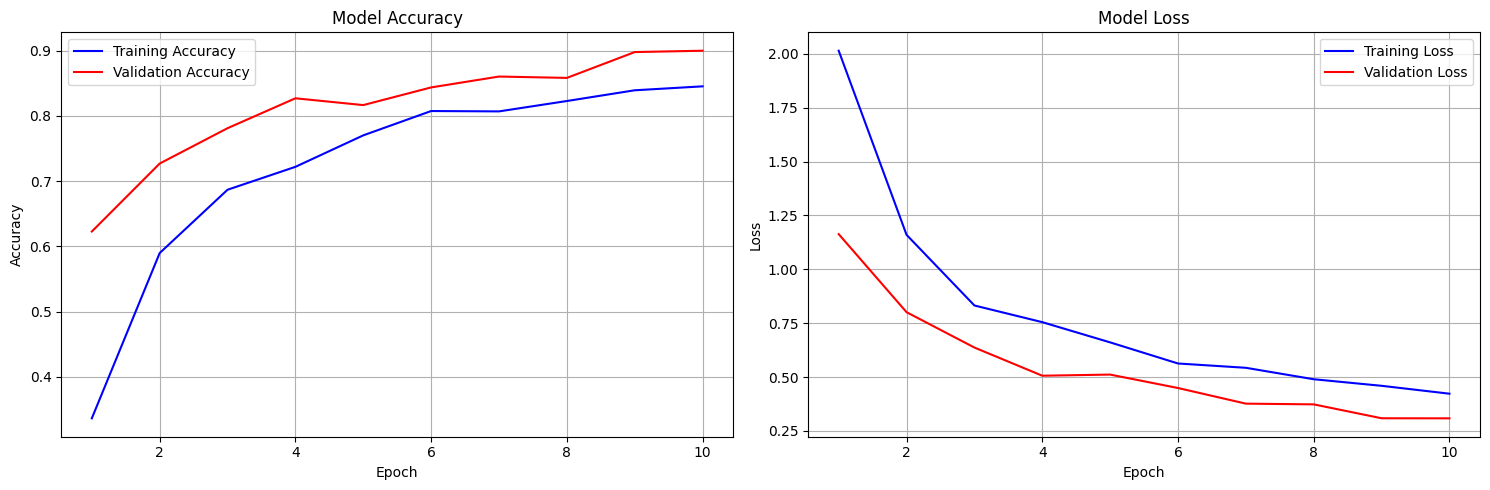

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy plot
total_epochs = 10

ax1.plot(range(1, total_epochs + 1), history.history['accuracy'], 'b-', label='Training Accuracy')
ax1.plot(range(1, total_epochs + 1), history.history['val_accuracy'], 'r-', label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(range(1, total_epochs + 1), history.history['loss'], 'b-', label='Training Loss')
ax2.plot(range(1, total_epochs + 1), history.history['val_loss'], 'r-', label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [18]:
# Final evaluation
print("\n" + "="*50)
print("FINAL MODEL EVALUATION")
print("="*50)

final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
best_val_acc = max(history.history['val_accuracy'])

print(f"Final Training Accuracy: {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
print(f"Final Validation Accuracy: {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")
print(f"Best Validation Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")


FINAL MODEL EVALUATION
Final Training Accuracy: 0.8454 (84.54%)
Final Validation Accuracy: 0.9000 (90.00%)
Best Validation Accuracy: 0.9000 (90.00%)


### Testing

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [21]:
# Get predictions from the test dataset
y_true = []  # True labels
y_pred = []  # Predicted labels

# Iterate through the test dataset to collect true labels and predictions
for images, labels in test_ds:
    predictions = densenet_model.predict(images)
    y_true.extend(labels.numpy())  # Append true labels
    y_pred.extend(np.argmax(predictions, axis=1))  # Append predicted labels

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 927ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 916ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 920ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 919ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 905ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


In [22]:
# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
error_rate = 1 - accuracy

print("\n" + "="*50)
print("MODEL EVALUATION METRICS")
print("="*50)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-Score (weighted): {f1:.4f}")
print(f"Error Rate: {error_rate:.4f} ({error_rate*100:.2f}%)")


MODEL EVALUATION METRICS
Accuracy: 0.8924 (89.24%)
Precision (weighted): 0.8912
Recall (weighted): 0.8924
F1-Score (weighted): 0.8909
Error Rate: 0.1076 (10.76%)


In [23]:
# Detailed classification report
print("\n" + "="*50)
print("DETAILED CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_true, y_pred, target_names=class_names))


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

   cardboard       0.94      0.91      0.93        35
       glass       0.89      0.96      0.93        53
       metal       0.91      0.85      0.88        34
       paper       0.88      0.91      0.89        54
     plastic       0.89      0.87      0.88        38
       trash       0.71      0.56      0.62         9

    accuracy                           0.89       223
   macro avg       0.87      0.84      0.85       223
weighted avg       0.89      0.89      0.89       223




CONFUSION MATRIX
Raw confusion matrix:
[[32  0  0  3  0  0]
 [ 0 51  0  0  2  0]
 [ 0  3 29  0  1  1]
 [ 2  1  1 49  0  1]
 [ 0  2  1  2 33  0]
 [ 0  0  1  2  1  5]]


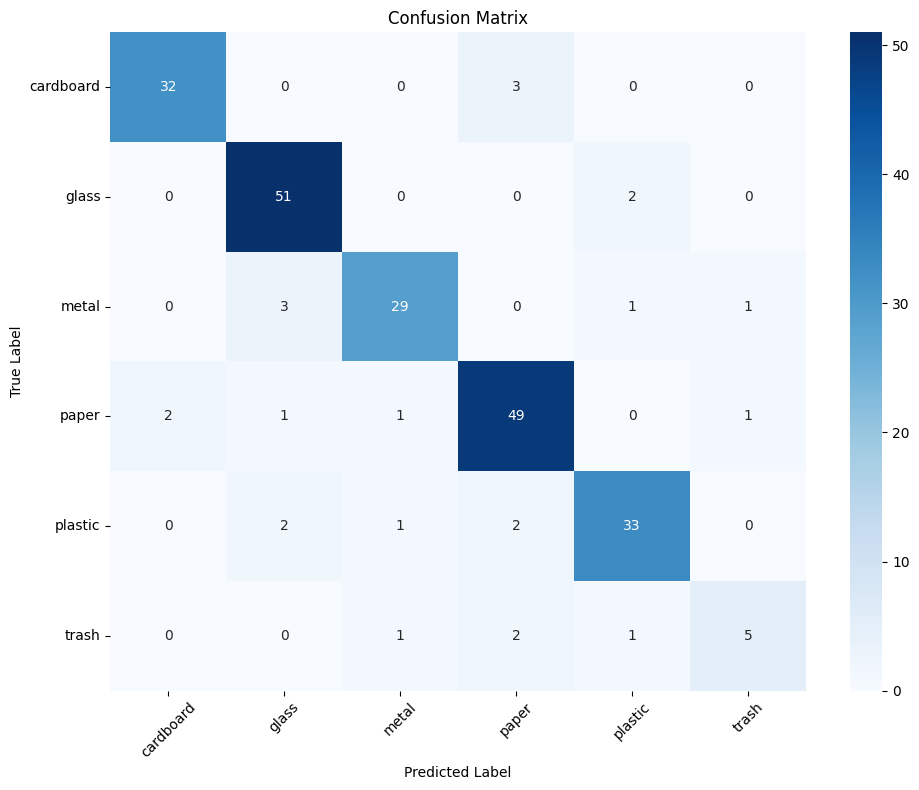

In [24]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("\n" + "="*50)
print("CONFUSION MATRIX")
print("="*50)
print("Raw confusion matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Save model

In [ ]:
# Save model
densenet_model.save('densenet121_model_v1.h5', save_format='h5')
print(f"\n Model saved as 'densenet121_model_v1.h5'")